<a href="https://www.kaggle.com/code/sofiatanganho/2-0-modela-o-treino?scriptVersionId=313951535" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Análise Preditiva do Mercado Imobiliário de Boston
#### Grupo 10: Diana Figueiredo, Natacha Zhang, Sofia Tanganho
#### Docente: Dora Melo 

## Importação de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from scipy.stats import kstest, norm

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    KFold,
    ParameterGrid,
    GridSearchCV,           
    RandomizedSearchCV,    
    cross_validate,        
    learning_curve          
)
from sklearn.pipeline import Pipeline                  
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,    
    davies_bouldin_score        
)

from xgboost import XGBRegressor

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/natachazhang/dados-processados/boston_processed.csv


In [3]:
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("/kaggle/input/datasets/natachazhang/dados-processados/boston_processed.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ZN          506 non-null    float64
 1   INDUS       506 non-null    float64
 2   CHAS        506 non-null    int64  
 3   AGE         506 non-null    float64
 4   TAX         506 non-null    float64
 5   B           506 non-null    float64
 6   MEDV        506 non-null    float64
 7   B_stand     506 non-null    float64
 8   ZN_stand    506 non-null    float64
 9   INDUS_norm  506 non-null    float64
 10  AGE_norm    506 non-null    float64
 11  TAX_norm    506 non-null    float64
 12  IQV         506 non-null    float64
 13  IAH         506 non-null    float64
 14  IQV_stand   506 non-null    float64
 15  IAH_stand   506 non-null    float64
dtypes: float64(15), int64(1)
memory usage: 63.4 KB


## Objetivo 1: Construir um modelo de previsão supervisionada do preço médio das habitações (MEDV), alcançando um R² superior a 0.80 e um RMSE inferior a 3.500 dólares, até ao Milestone 3.
### Baseline: 
- Regressão Linear 
### Algoritmos candidatos:
- Random Forest
- XGBoost
- SVR




### Experimentação de valores para treino de 80% e teste de 20%

In [5]:
# Divisão 80% treino / 20% teste
X = df[[
    'ZN_stand',      
    'INDUS_norm',   
    'CHAS',          
    'AGE_norm',      
    'TAX_norm',     
    'B_stand',       
    'IQV_stand',    
    'IAH_stand'     
]]

y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (404, 8)
Teste: (102, 8)


In [6]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

rmse_bl = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_bl = mean_absolute_error(y_test, y_pred_baseline)
r2_bl = r2_score(y_test, y_pred_baseline)

print('Regressão Linear')
print(f"RMSE: {rmse_bl:.4f}")
print(f"MAE:  {mae_bl:.4f}")
print(f"R²:   {r2_bl:.4f}")

Regressão Linear
RMSE: 4.7511
MAE:  3.3544
R²:   0.6922


In [7]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print("Random Forest")
print(f"RMSE Treino: {rmse_rf_train:.4f} | RMSE Teste: {rmse_rf_test:.4f}")
print(f"MAE  Treino: {mae_rf_train:.4f} | MAE  Teste: {mae_rf_test:.4f}")
print(f"R²   Treino: {r2_rf_train:.4f} | R²   Teste: {r2_rf_test:.4f}")

Random Forest
RMSE Treino: 1.5205 | RMSE Teste: 3.8309
MAE  Treino: 1.0570 | MAE  Teste: 2.6729
R²   Treino: 0.9734 | R²   Teste: 0.7999


In [8]:
# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test = xgb.predict(X_test)

rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

print("XGBOOST")
print(f"RMSE Treino: {rmse_xgb_train:.4f} | RMSE Teste: {rmse_xgb_test:.4f}")
print(f"MAE  Treino: {mae_xgb_train:.4f} | MAE  Teste: {mae_xgb_test:.4f}")
print(f"R²   Treino: {r2_xgb_train:.4f} | R²   Teste: {r2_xgb_test:.4f}")

XGBOOST
RMSE Treino: 0.0509 | RMSE Teste: 3.6863
MAE  Treino: 0.0356 | MAE  Teste: 2.7311
R²   Treino: 1.0000 | R²   Teste: 0.8147


In [9]:
# SVR precisa de dados normalizados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinar SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

# Métricas Treino
y_pred_svr_train = svr.predict(X_train_scaled)
rmse_svr_train = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))
mae_svr_train = mean_absolute_error(y_train, y_pred_svr_train)
r2_svr_train = r2_score(y_train, y_pred_svr_train)

# Métricas Teste
y_pred_svr_test = svr.predict(X_test_scaled)
rmse_svr_test = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))
mae_svr_test = mean_absolute_error(y_test, y_pred_svr_test)
r2_svr_test = r2_score(y_test, y_pred_svr_test)

print("SVR")
print(f"RMSE Treino: {rmse_svr_train:.4f} | RMSE Teste: {rmse_svr_test:.4f}")
print(f"MAE  Treino: {mae_svr_train:.4f} | MAE  Teste: {mae_svr_test:.4f}")
print(f"R²   Treino: {r2_svr_train:.4f} | R²   Teste: {r2_svr_test:.4f}")

SVR
RMSE Treino: 5.8203 | RMSE Teste: 5.7306
MAE  Treino: 3.8342 | MAE  Teste: 3.4481
R²   Treino: 0.6101 | R²   Teste: 0.5522


In [10]:
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'SVR'],
    'RMSE Treino': [ rmse_rf_train, rmse_xgb_train, rmse_svr_train],
    'RMSE Teste':  [ rmse_rf_test, rmse_xgb_test, rmse_svr_test],
    'MAE Treino':  [ mae_rf_train, mae_xgb_train, mae_svr_train],
    'MAE Teste':   [ mae_rf_test, mae_xgb_test, mae_svr_test],
    'R² Treino':   [ r2_rf_train, r2_xgb_train, r2_svr_train],
    'R² Teste':    [ r2_rf_test, r2_xgb_test, r2_svr_test]
})

print("Resultados dos modelos usando divisão treino/teste (80%/20%)")
print(resultados.to_string(index=False))

Resultados dos modelos usando divisão treino/teste (80%/20%)
       Modelo  RMSE Treino  RMSE Teste  MAE Treino  MAE Teste  R² Treino  R² Teste
Random Forest     1.520516    3.830944    1.056970   2.672922   0.973387  0.799872
      XGBoost     0.050864    3.686294    0.035627   2.731074   0.999970  0.814700
          SVR     5.820313    5.730591    3.834192   3.448100   0.610053  0.552189


### Experimentação de valores para treino de 70% e teste de 30%

In [11]:
X = df[[
    'ZN_stand',      
    'INDUS_norm',    
    'CHAS',          
    'AGE_norm',      
    'TAX_norm',      
    'B_stand',       
    'IQV_stand',   
    'IAH_stand'      
]]

y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (354, 8)
Teste: (152, 8)


In [12]:
# Treinar Baseline
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)


rmse_bl = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_bl = mean_absolute_error(y_test, y_pred_baseline)
r2_bl = r2_score(y_test, y_pred_baseline)

print("Regressão Linear")
print(f"RMSE: {rmse_bl:.4f}")
print(f"MAE:  {mae_bl:.4f}")
print(f"R²:   {r2_bl:.4f}")

Regressão Linear
RMSE: 4.8757
MAE:  3.5549
R²:   0.6810


In [13]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print("RANDOM FOREST")
print(f"RMSE Treino: {rmse_rf_train:.4f} | RMSE Teste: {rmse_rf_test:.4f}")
print(f"MAE  Treino: {mae_rf_train:.4f} | MAE  Teste: {mae_rf_test:.4f}")
print(f"R²   Treino: {r2_rf_train:.4f} | R²   Teste: {r2_rf_test:.4f}")

RANDOM FOREST
RMSE Treino: 1.6594 | RMSE Teste: 3.5936
MAE  Treino: 1.1323 | MAE  Teste: 2.5627
R²   Treino: 0.9687 | R²   Teste: 0.8267


In [14]:
# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test = xgb.predict(X_test)

rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

print("XGBOOST")
print(f"RMSE Treino: {rmse_xgb_train:.4f} | RMSE Teste: {rmse_xgb_test:.4f}")
print(f"MAE  Treino: {mae_xgb_train:.4f} | MAE  Teste: {mae_xgb_test:.4f}")
print(f"R²   Treino: {r2_xgb_train:.4f} | R²   Teste: {r2_xgb_test:.4f}")

XGBOOST
RMSE Treino: 0.0561 | RMSE Teste: 3.7102
MAE  Treino: 0.0382 | MAE  Teste: 2.7212
R²   Treino: 1.0000 | R²   Teste: 0.8153


In [15]:
# SVR precisa de dados normalizados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinar SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

# Métricas Treino
y_pred_svr_train = svr.predict(X_train_scaled)
rmse_svr_train = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))
mae_svr_train = mean_absolute_error(y_train, y_pred_svr_train)
r2_svr_train = r2_score(y_train, y_pred_svr_train)

# Métricas Teste
y_pred_svr_test = svr.predict(X_test_scaled)
rmse_svr_test = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))
mae_svr_test = mean_absolute_error(y_test, y_pred_svr_test)
r2_svr_test = r2_score(y_test, y_pred_svr_test)

print("SVR")
print(f"RMSE Treino: {rmse_svr_train:.4f} | RMSE Teste: {rmse_svr_test:.4f}")
print(f"MAE  Treino: {mae_svr_train:.4f} | MAE  Teste: {mae_svr_test:.4f}")
print(f"R²   Treino: {r2_svr_train:.4f} | R²   Teste: {r2_svr_test:.4f}")

SVR
RMSE Treino: 6.0765 | RMSE Teste: 5.7668
MAE  Treino: 4.0072 | MAE  Teste: 3.7572
R²   Treino: 0.5799 | R²   Teste: 0.5537


In [16]:
# Tabela Comparativa
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'SVR'],
    'RMSE Treino': [ rmse_rf_train, rmse_xgb_train, rmse_svr_train],
    'RMSE Teste':  [ rmse_rf_test, rmse_xgb_test, rmse_svr_test],
    'MAE Treino':  [ mae_rf_train, mae_xgb_train, mae_svr_train],
    'MAE Teste':   [ mae_rf_test, mae_xgb_test, mae_svr_test],
    'R² Treino':   [ r2_rf_train, r2_xgb_train, r2_svr_train],
    'R² Teste':    [ r2_rf_test, r2_xgb_test, r2_svr_test]
})

print("Resultados dos modelos usando divisão treino/teste (70%/30%)")
print(resultados.to_string(index=False))

Resultados dos modelos usando divisão treino/teste (70%/30%)
       Modelo  RMSE Treino  RMSE Teste  MAE Treino  MAE Teste  R² Treino  R² Teste
Random Forest     1.659362    3.593610    1.132251   2.562664   0.968674  0.826688
      XGBoost     0.056141    3.710183    0.038237   2.721180   0.999964  0.815261
          SVR     6.076497    5.766803    4.007240   3.757188   0.579917  0.553689


##  Avaliação de Ajuste (Fit) 

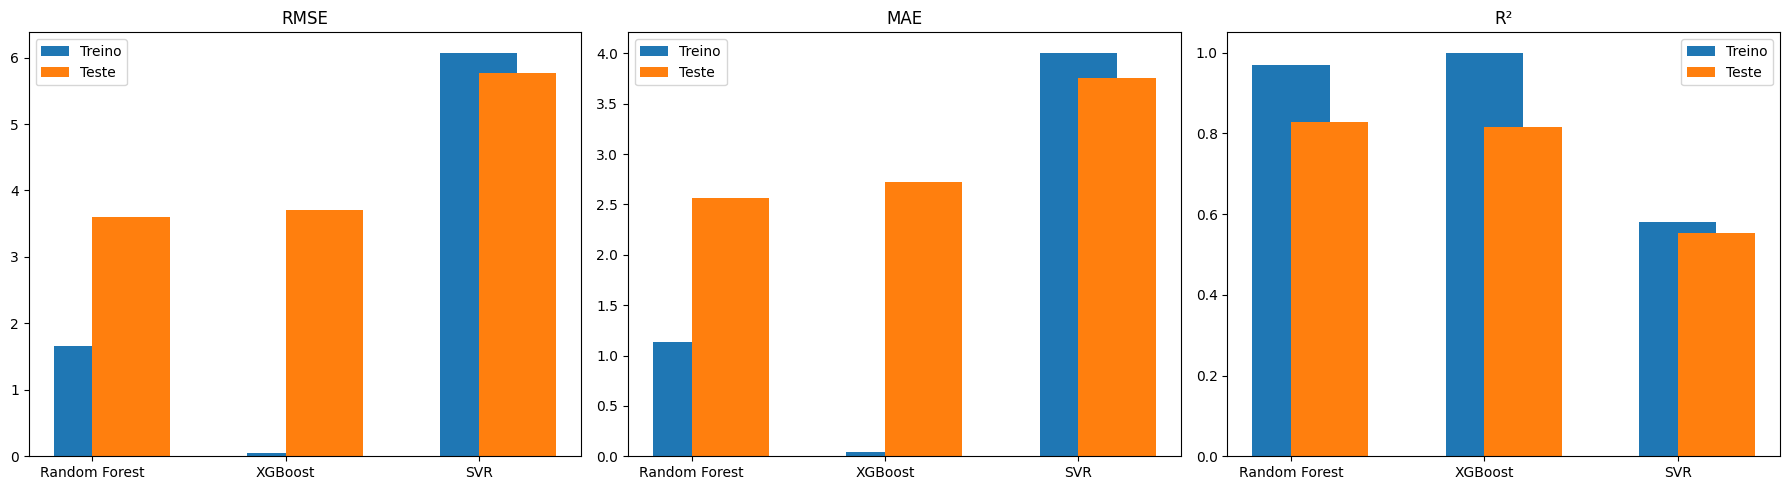

In [17]:
modelos = ['Random Forest', 'XGBoost', 'SVR']
x = range(len(modelos))

rmse_train = [rmse_rf_train, rmse_xgb_train, rmse_svr_train]
rmse_test  = [rmse_rf_test,  rmse_xgb_test,  rmse_svr_test]

mae_train = [mae_rf_train, mae_xgb_train, mae_svr_train]
mae_test  = [mae_rf_test,  mae_xgb_test,  mae_svr_test]

r2_train = [r2_rf_train, r2_xgb_train, r2_svr_train]
r2_test  = [r2_rf_test,  r2_xgb_test,  r2_svr_test]


fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].bar(x, rmse_train, width=0.4, label='Treino', align='center')
axes[0].bar(x, rmse_test,  width=0.4, label='Teste', align='edge')
axes[0].set_title('RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos)
axes[0].legend()


axes[1].bar(x, mae_train, width=0.4, label='Treino', align='center')
axes[1].bar(x, mae_test,  width=0.4, label='Teste', align='edge')
axes[1].set_title('MAE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos)
axes[1].legend()


axes[2].bar(x, r2_train, width=0.4, label='Treino', align='center')
axes[2].bar(x, r2_test,  width=0.4, label='Teste', align='edge')
axes[2].set_title('R²')
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos)
axes[2].legend()

plt.tight_layout()
plt.show()

In [18]:
def diagnostico_fit(rmse_train, rmse_test, 
                   mae_train, mae_test, 
                   r2_train, r2_test, 
                   nome_modelo):
    
    print(f"{nome_modelo}")
    print(f"RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")
    print(f"MAE  treino: {mae_train:.4f}  | MAE  teste: {mae_test:.4f}")
    print(f"R2   treino: {r2_train:.4f} | R2   teste: {r2_test:.4f}")

    # Diferenças
    diff_r2   = r2_train - r2_test
    diff_rmse = rmse_test - rmse_train
    diff_mae  = mae_test - mae_train

    # Diagnóstico
    if r2_train > 0.9 and diff_r2 > 0.1 and diff_rmse > 0 and diff_mae > 0:
        print("Diagnóstico: Overfitting (sobreajuste)")
    
    elif r2_train < 0.7 and r2_test < 0.7:
        print("Diagnóstico: Underfitting (subajuste)")
    
    else:
        print("Diagnóstico: Bom ajuste")
    
diagnostico_fit(rmse_rf_train, rmse_rf_test, mae_rf_train, mae_rf_test,r2_rf_train, r2_rf_test,"Random Forest")

diagnostico_fit(rmse_xgb_train, rmse_xgb_test, mae_xgb_train, mae_xgb_test, r2_xgb_train, r2_xgb_test, "XGBoost")

diagnostico_fit(rmse_svr_train, rmse_svr_test, mae_svr_train, mae_svr_test, r2_svr_train, r2_svr_test,"SVR")

Random Forest
RMSE treino: 1.6594 | RMSE teste: 3.5936
MAE  treino: 1.1323  | MAE  teste: 2.5627
R2   treino: 0.9687 | R2   teste: 0.8267
Diagnóstico: Overfitting (sobreajuste)
XGBoost
RMSE treino: 0.0561 | RMSE teste: 3.7102
MAE  treino: 0.0382  | MAE  teste: 2.7212
R2   treino: 1.0000 | R2   teste: 0.8153
Diagnóstico: Overfitting (sobreajuste)
SVR
RMSE treino: 6.0765 | RMSE teste: 5.7668
MAE  treino: 4.0072  | MAE  teste: 3.7572
R2   treino: 0.5799 | R2   teste: 0.5537
Diagnóstico: Underfitting (subajuste)


## Sintonização Fina (Hyperparameter Tuning)

In [19]:
# Random Forest
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
}
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
gs_rf.fit(X_train, y_train)
rf_tuned        = gs_rf.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
rmse_rf_tuned   = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned     = r2_score(y_test, y_pred_rf_tuned)

print('RANDOM FOREST — Melhores hiperparametros:', gs_rf.best_params_)
print(f'  RMSE Teste (tuned): {rmse_rf_tuned:.4f}')
print(f'  R2   Teste (tuned): {r2_rf_tuned:.4f}')
print()

# XGBoost
param_dist_xgb = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 5, 7, 9],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}
rs_xgb = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_dist_xgb, n_iter=30, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=0
)
rs_xgb.fit(X_train, y_train)
xgb_tuned        = rs_xgb.best_estimator_
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
rmse_xgb_tuned   = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned     = r2_score(y_test, y_pred_xgb_tuned)

print('XGBOOST — Melhores hiperparametros:', rs_xgb.best_params_)
print(f'  RMSE Teste (tuned): {rmse_xgb_tuned:.4f}')
print(f'  R2   Teste (tuned): {r2_xgb_tuned:.4f}')
print()

# SVR
pipeline_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR())
])
param_grid_svr = {
    'svr__C':       [0.1, 1, 10, 100],
    'svr__epsilon': [0.1, 0.5, 1.0],
    'svr__kernel':  ['rbf', 'linear'],
}
gs_svr = GridSearchCV(
    pipeline_svr, param_grid_svr, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
gs_svr.fit(X_train, y_train)
svr_tuned        = gs_svr.best_estimator_
y_pred_svr_tuned = svr_tuned.predict(X_test)
rmse_svr_tuned   = np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned))
r2_svr_tuned     = r2_score(y_test, y_pred_svr_tuned)

print('SVR — Melhores hiperparametros:', gs_svr.best_params_)
print(f'  RMSE Teste (tuned): {rmse_svr_tuned:.4f}')
print(f'  R2   Teste (tuned): {r2_svr_tuned:.4f}')
print()

# Tabela comparativa base vs tuned
df_tuning = pd.DataFrame([
    {'Modelo': 'Random Forest (base)',  'RMSE': rmse_rf_test,   'R2': r2_rf_test},
    {'Modelo': 'Random Forest (tuned)', 'RMSE': rmse_rf_tuned,  'R2': r2_rf_tuned},
    {'Modelo': 'XGBoost (base)',        'RMSE': rmse_xgb_test,  'R2': r2_xgb_test},
    {'Modelo': 'XGBoost (tuned)',       'RMSE': rmse_xgb_tuned, 'R2': r2_xgb_tuned},
    {'Modelo': 'SVR (base)',            'RMSE': rmse_svr_test,  'R2': r2_svr_test},
    {'Modelo': 'SVR (tuned)',           'RMSE': rmse_svr_tuned, 'R2': r2_svr_tuned},
])
print('Tabela Comparativa — Antes e Depois do Tuning')
print(df_tuning.to_string(index=False))

RANDOM FOREST — Melhores hiperparametros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  RMSE Teste (tuned): 3.5936
  R2   Teste (tuned): 0.8267

XGBOOST — Melhores hiperparametros: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  RMSE Teste (tuned): 3.4510
  R2   Teste (tuned): 0.8402

SVR — Melhores hiperparametros: {'svr__C': 10, 'svr__epsilon': 1.0, 'svr__kernel': 'rbf'}
  RMSE Teste (tuned): 4.3490
  R2   Teste (tuned): 0.7462

Tabela Comparativa — Antes e Depois do Tuning
               Modelo     RMSE       R2
 Random Forest (base) 3.593610 0.826688
Random Forest (tuned) 3.593610 0.826688
       XGBoost (base) 3.710183 0.815261
      XGBoost (tuned) 3.450985 0.840172
           SVR (base) 5.766803 0.553689
          SVR (tuned) 4.349008 0.746167


## Validação de Robustez

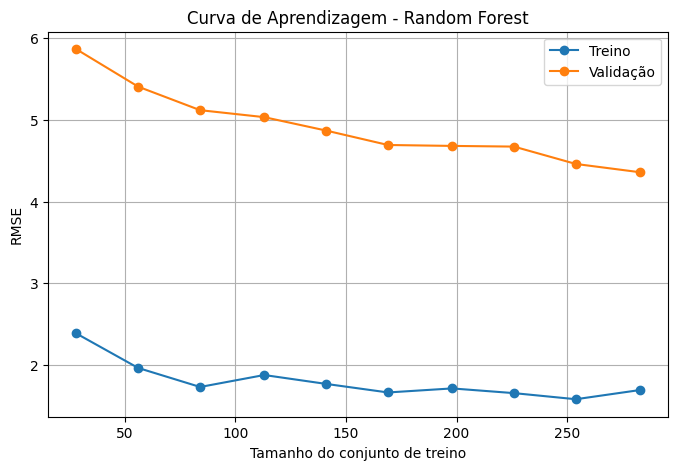

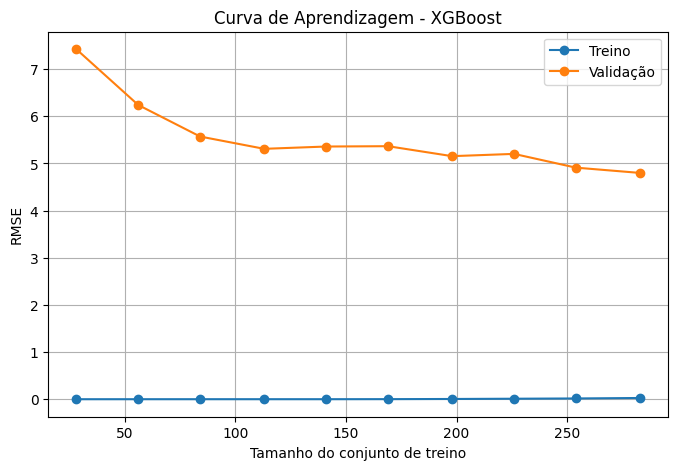

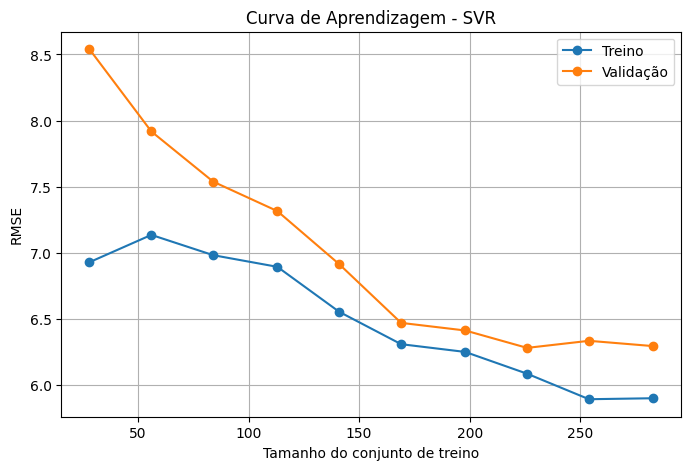

In [20]:
def plot_learning_curve(model, X, y, nome_modelo):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = -train_scores.mean(axis=1)
    test_mean = -test_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', label='Treino')
    plt.plot(train_sizes, test_mean, 'o-', label='Validação')
    plt.title(f'Curva de Aprendizagem - {nome_modelo}')
    plt.xlabel('Tamanho do conjunto de treino')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid()
    plt.show()

if 'rf' in globals():
    plot_learning_curve(rf, X_train, y_train, "Random Forest")

if 'xgb' in globals():
    plot_learning_curve(xgb, X_train, y_train, "XGBoost")

if 'svr' in globals():
    plot_learning_curve(svr, X_train, y_train, "SVR")

## Validação Cruzada (K-Fold Cross-Validation)

K-Fold Cross-Validation (k=5) — Regressão

          Modelo  RMSE Média  RMSE Std  MAE Média  MAE Std  R2 Média  R2 Std
Regressão Linear      5.0022    0.2573     3.6314   0.1825    0.6962  0.0457
   Random Forest      4.0734    0.5166     2.8906   0.3166    0.7955  0.0546
         XGBoost      4.3250    0.6213     3.0321   0.2793    0.7699  0.0661
             SVR      6.0755    0.4100     4.0053   0.3687    0.5560  0.0318


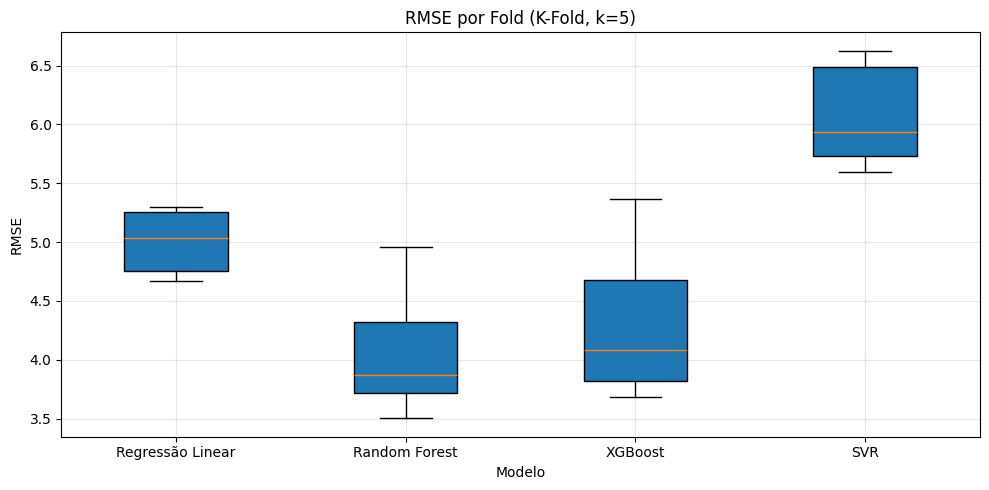

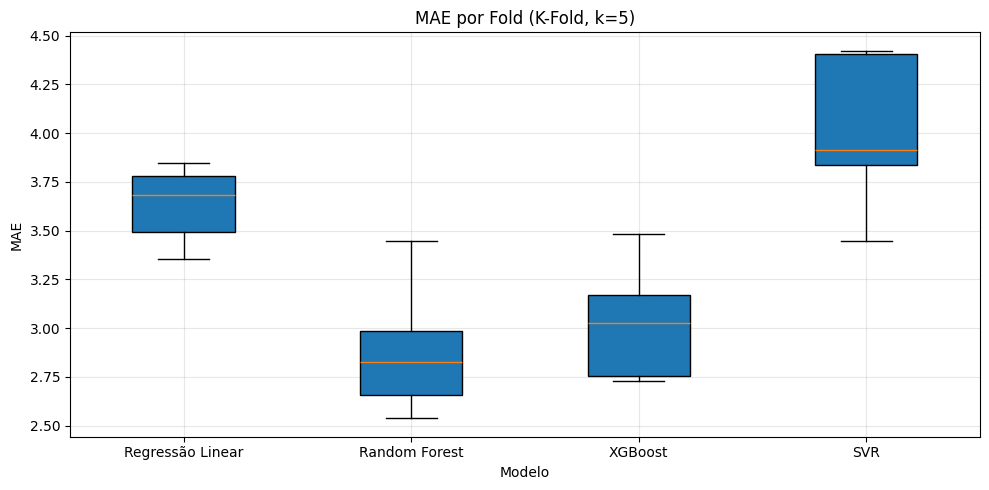

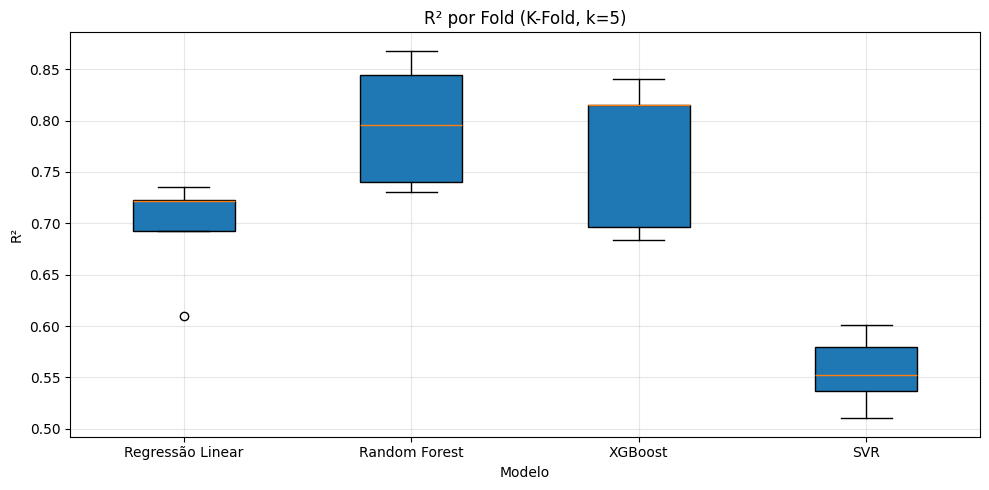

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)


scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE':  'neg_mean_absolute_error',
    'R2':   'r2'
}


modelos_cv = {
    'Regressão Linear': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'SVR': Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))])
}

# Resultados
resultados_cv = []
rmse_por_modelo = {}
mae_por_modelo = {}
r2_por_modelo = {}

for nome, modelo in modelos_cv.items():
    cv_res = cross_validate(modelo, X, y, cv=kf, scoring=scoring, n_jobs=-1)

    rmse = -cv_res['test_RMSE']
    mae  = -cv_res['test_MAE']
    r2   = cv_res['test_R2']

    rmse_por_modelo[nome] = rmse
    mae_por_modelo[nome]  = mae
    r2_por_modelo[nome]   = r2

    resultados_cv.append({
        'Modelo': nome,
        'RMSE Média': round(rmse.mean(), 4),
        'RMSE Std':   round(rmse.std(), 4),
        'MAE Média':  round(mae.mean(), 4),
        'MAE Std':    round(mae.std(), 4),
        'R2 Média':   round(r2.mean(), 4),
        'R2 Std':     round(r2.std(), 4),
    })


df_cv = pd.DataFrame(resultados_cv)
print("K-Fold Cross-Validation (k=5) — Regressão\n")
print(df_cv.to_string(index=False))


def plot_boxplot(dados, titulo, ylabel):
    plt.figure(figsize=(10,5))
    plt.boxplot(dados.values(), labels=dados.keys(), patch_artist=True)
    plt.title(titulo)
    plt.ylabel(ylabel)
    plt.xlabel('Modelo')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_boxplot(rmse_por_modelo, 'RMSE por Fold (K-Fold, k=5)', 'RMSE')
plot_boxplot(mae_por_modelo,  'MAE por Fold (K-Fold, k=5)',  'MAE')
plot_boxplot(r2_por_modelo,   'R² por Fold (K-Fold, k=5)',   'R²')

## Análise de Resultados

Modelo selecionado para analise de residuos: XGBoost (tuned)


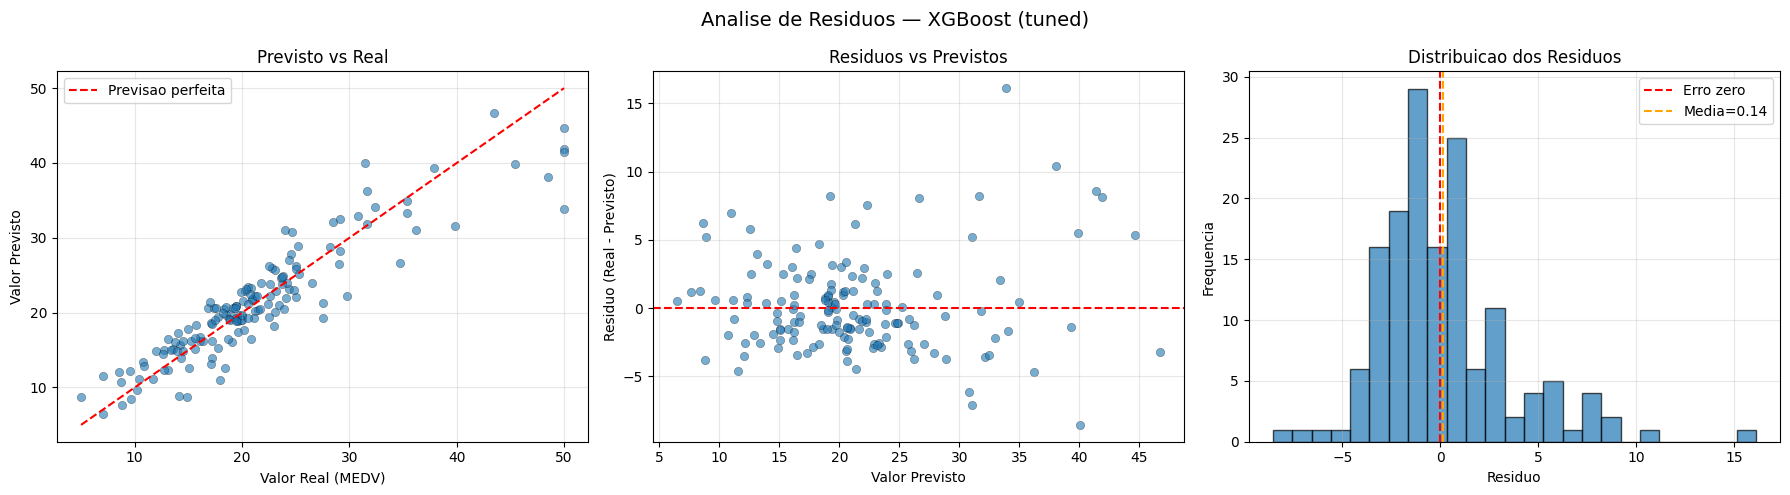


Estatisticas dos Residuos — XGBoost (tuned)
  Residuo medio  : 0.1397  (proximo de 0 = sem bias sistematico)
  Desvio padrao  : 3.4482
  Erro maximo    : 16.1031
  Erro minimo    : -8.5541
  % casos |erro| < 2k$: 51.3%
  % casos |erro| < 5k$: 87.5%

Top 10 piores previsoes:
     MEDV_real  MEDV_previsto   Erro_abs
371       50.0      33.896896  16.103104
203       48.5      38.074177  10.425823
225       50.0      41.406567   8.593433
229       31.5      40.054073   8.554073
409       27.5      19.259350   8.240650
180       39.8      31.626001   8.173999
195       50.0      41.880703   8.119297
2         34.7      26.604263   8.095737
473       29.8      22.282049   7.517951
0         24.0      31.091410   7.091410


In [22]:
# Seleciona automaticamente o modelo tuned com menor RMSE
melhor_rmse = min(rmse_rf_tuned, rmse_xgb_tuned, rmse_svr_tuned)
if melhor_rmse == rmse_rf_tuned:
    nome_modelo_final = 'Random Forest (tuned)'
    y_pred_final = y_pred_rf_tuned
elif melhor_rmse == rmse_xgb_tuned:
    nome_modelo_final = 'XGBoost (tuned)'
    y_pred_final = y_pred_xgb_tuned
else:
    nome_modelo_final = 'SVR (tuned)'
    y_pred_final = y_pred_svr_tuned

print(f'Modelo selecionado para analise de residuos: {nome_modelo_final}')

residuos = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Previsto vs Real
axes[0].scatter(y_test, y_pred_final, alpha=0.6, edgecolors='k', linewidths=0.3)
lim = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lim, lim, 'r--', label='Previsao perfeita')
axes[0].set_xlabel('Valor Real (MEDV)')
axes[0].set_ylabel('Valor Previsto')
axes[0].set_title('Previsto vs Real')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuos vs Previstos
axes[1].scatter(y_pred_final, residuos, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Valor Previsto')
axes[1].set_ylabel('Residuo (Real - Previsto)')
axes[1].set_title('Residuos vs Previstos')
axes[1].grid(True, alpha=0.3)

# Distribuicao dos Residuos
axes[2].hist(residuos, bins=25, edgecolor='k', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', label='Erro zero')
axes[2].axvline(residuos.mean(), color='orange', linestyle='--',
                label=f'Media={residuos.mean():.2f}')
axes[2].set_xlabel('Residuo')
axes[2].set_ylabel('Frequencia')
axes[2].set_title('Distribuicao dos Residuos')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Analise de Residuos — {nome_modelo_final}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nEstatisticas dos Residuos — {nome_modelo_final}')
print(f'  Residuo medio  : {residuos.mean():.4f}  (proximo de 0 = sem bias sistematico)')
print(f'  Desvio padrao  : {residuos.std():.4f}')
print(f'  Erro maximo    : {residuos.max():.4f}')
print(f'  Erro minimo    : {residuos.min():.4f}')
print(f'  % casos |erro| < 2k$: {(np.abs(residuos) < 2).mean()*100:.1f}%')
print(f'  % casos |erro| < 5k$: {(np.abs(residuos) < 5).mean()*100:.1f}%')

df_erros = X_test.copy()
df_erros['MEDV_real']     = y_test.values
df_erros['MEDV_previsto'] = y_pred_final
df_erros['Erro_abs']      = np.abs(residuos)
df_erros = df_erros.sort_values('Erro_abs', ascending=False)
print('\nTop 10 piores previsoes:')
print(df_erros[['MEDV_real', 'MEDV_previsto', 'Erro_abs']].head(10).to_string())

Importancia de Variaveis:
   Feature  Random Forest  XGBoost
 IAH_stand       0.590397 0.285483
 IQV_stand       0.116766 0.081546
  AGE_norm       0.083127 0.070973
INDUS_norm       0.077707 0.143550
  TAX_norm       0.059965 0.145220
   B_stand       0.049034 0.046492
  ZN_stand       0.017987 0.078813
      CHAS       0.005017 0.147923


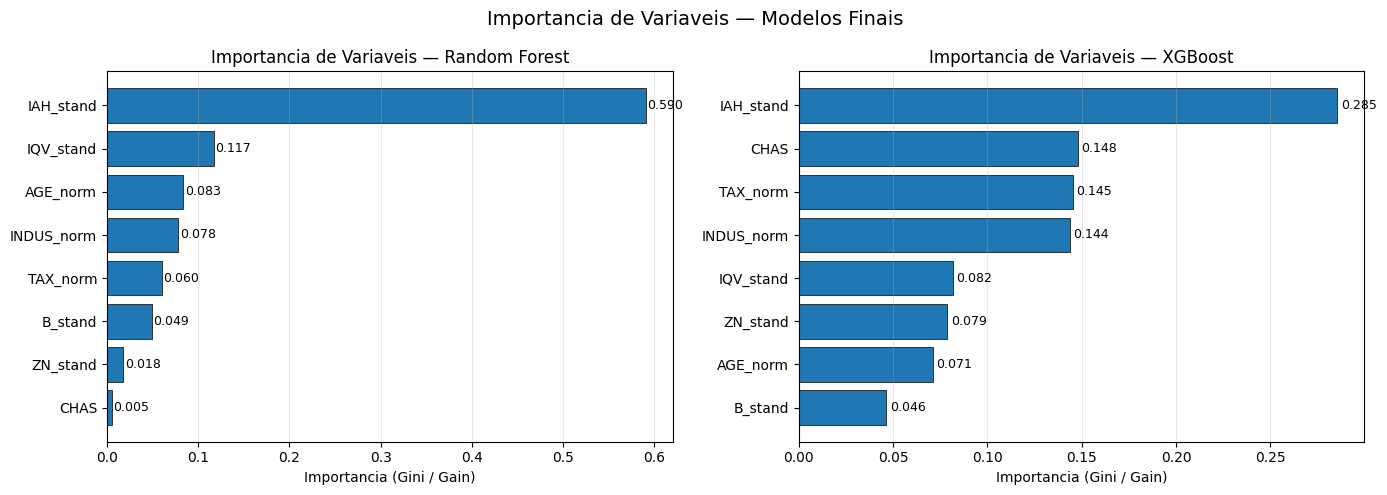

SELECAO DO MODELO FINAL
                 Modelo     RMSE       R2
        XGBoost (tuned) 3.450985 0.840172
  Random Forest (tuned) 3.593610 0.826688
            SVR (tuned) 4.349008 0.746167
Regressao Linear (base) 4.875704 0.680962

Modelo eleito : XGBoost (tuned)
RMSE (teste)  : 3.4510  (erro medio de 3.45k$ no preco das casas)
R2 (teste)    : 0.8402  (84.0% da variancia do preco explicada)
Criterio      : menor RMSE no conjunto de teste com dados nunca vistos
Melhoria face ao baseline (Reg. Linear RMSE=4.8757): 1.4247



In [23]:
feature_names = [
    'ZN_stand', 'INDUS_norm', 'CHAS', 'AGE_norm',
    'TAX_norm', 'B_stand', 'IQV_stand', 'IAH_stand'
]

importancias_rf  = rf_tuned.feature_importances_
importancias_xgb = xgb_tuned.feature_importances_

df_imp = pd.DataFrame({
    'Feature':       feature_names,
    'Random Forest': importancias_rf,
    'XGBoost':       importancias_xgb,
}).sort_values('Random Forest', ascending=False)

print('Importancia de Variaveis:')
print(df_imp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Random Forest', 'XGBoost']):
    df_plot = df_imp.sort_values(col, ascending=True)
    bars = ax.barh(df_plot['Feature'], df_plot[col], edgecolor='k', linewidth=0.5)
    ax.set_title(f'Importancia de Variaveis — {col}', fontsize=12)
    ax.set_xlabel('Importancia (Gini / Gain)')
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, df_plot[col]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Importancia de Variaveis — Modelos Finais', fontsize=14)
plt.tight_layout()
plt.show()



print('SELECAO DO MODELO FINAL')


resumo_final = pd.DataFrame([
    {'Modelo': 'Regressao Linear (base)', 'RMSE': rmse_bl,        'R2': r2_bl},
    {'Modelo': 'Random Forest (tuned)',   'RMSE': rmse_rf_tuned,  'R2': r2_rf_tuned},
    {'Modelo': 'XGBoost (tuned)',         'RMSE': rmse_xgb_tuned, 'R2': r2_xgb_tuned},
    {'Modelo': 'SVR (tuned)',             'RMSE': rmse_svr_tuned, 'R2': r2_svr_tuned},
]).sort_values('RMSE')

print(resumo_final.to_string(index=False))

modelo_eleito = resumo_final.iloc[0]
nome_eleito   = modelo_eleito['Modelo']
rmse_eleito   = modelo_eleito['RMSE']
r2_eleito     = modelo_eleito['R2']

print(f'''
Modelo eleito : {nome_eleito}
RMSE (teste)  : {rmse_eleito:.4f}  (erro medio de {rmse_eleito:.2f}k$ no preco das casas)
R2 (teste)    : {r2_eleito:.4f}  ({r2_eleito*100:.1f}% da variancia do preco explicada)
Criterio      : menor RMSE no conjunto de teste com dados nunca vistos
Melhoria face ao baseline (Reg. Linear RMSE={rmse_bl:.4f}): {rmse_bl - rmse_eleito:.4f}
''')

## Objetivo 2: Criar um modelo de Clustering para segmentar as habitações em perfis distintos com base nas suas características socioeconómicas, habitacionais e ambientais, validado pelo método do cotovelo e por um Coeficiente de Silhueta (>0.50), até ao Milestone 3
### Baseline: 
- Kmeans
### Algoritmos candidatos:
-  KMeans otimizado
- Agglomerative
- DBSCAN
  

In [24]:
feature_priority = {
    "ZN": ["ZN_stand", "ZN_norm", "ZN"],
    "INDUS": ["INDUS_stand", "INDUS_norm", "INDUS"],
    "CHAS": ["CHAS"],
    "AGE": ["AGE_stand", "AGE_norm", "AGE"],
    "TAX": ["TAX_stand", "TAX_norm", "TAX"],
    "B": ["B_stand", "B_norm", "B"],
    "IQV": ["IQV_stand", "IQV_norm", "IQV"],
    "IAH": ["IAH_stand", "IAH_norm", "IAH"],
}


selected_features = []
feature_origin_map = {}

for base_name, candidates in feature_priority.items():
    chosen = next((col for col in candidates if col in df.columns), None)
    if chosen is not None:
        selected_features.append(chosen)
        feature_origin_map[chosen] = base_name

if not selected_features:
    raise ValueError("Nenhuma das colunas esperadas para clustering foi encontrada no dataframe.")

X = df[selected_features].copy()

print("Variáveis usadas no clustering:")
print(selected_features)
print("\nShape do dataset de clustering:", X.shape)

Variáveis usadas no clustering:
['ZN_stand', 'INDUS_norm', 'CHAS', 'AGE_norm', 'TAX_norm', 'B_stand', 'IQV_stand', 'IAH_stand']

Shape do dataset de clustering: (506, 8)


# Divisão em treino e teste para avaliar a estabilidade

In [25]:
X_train, X_test = train_test_split(X, test_size=0.30, random_state=42)

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)



Train: (354, 8)
Test : (152, 8)


In [26]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)


def get_valid_labels(labels):
    labels = np.asarray(labels)
    mask = labels != -1  # remove ruído do DBSCAN
    valid_labels = labels[mask]
    return mask, valid_labels


def safe_silhouette(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return silhouette_score(X_part[mask], valid_labels)


def safe_calinski(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return calinski_harabasz_score(X_part[mask], valid_labels)


def safe_davies(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return davies_bouldin_score(X_part[mask], valid_labels)


def count_clusters(labels):
    labels = np.asarray(labels)
    unique = set(labels)
    if -1 in unique:
        unique.remove(-1)
    return len(unique)



def evaluate_on_split(model, X_part):
    labels = model.fit_predict(X_part)

    silhouette = safe_silhouette(X_part, labels)
    calinski = safe_calinski(X_part, labels)
    davies = safe_davies(X_part, labels)

    n_clusters = count_clusters(labels)
    noise = int(np.sum(np.asarray(labels) == -1))
    inertia = getattr(model, "inertia_", np.nan)

    return {
        "labels": labels,
        "silhouette": silhouette,
        "calinski": calinski,
        "davies": davies,
        "n_clusters": n_clusters,
        "noise_points": noise,
        "inertia": inertia
    }


def evaluate_train_test(model_train, model_test, model_name):
    train_res = evaluate_on_split(model_train, X_train)
    test_res  = evaluate_on_split(model_test, X_test)

    return {
        "Modelo": model_name,

        "Silhouette_Treino": train_res["silhouette"],
        "Silhouette_Teste": test_res["silhouette"],

        "Calinski_Treino": train_res["calinski"],
        "Calinski_Teste": test_res["calinski"],

        "Davies_Treino": train_res["davies"],
        "Davies_Teste": test_res["davies"],

        "Clusters_Treino": train_res["n_clusters"],
        "Clusters_Teste": test_res["n_clusters"],

        "Ruido_Treino": train_res["noise_points"],
        "Ruido_Teste": test_res["noise_points"],

        "Inertia_Treino": train_res["inertia"],
        "Inertia_Teste": test_res["inertia"],

        "Labels_Treino": train_res["labels"],
        "Labels_Teste": test_res["labels"]
    }

# Baseline - KMeans

In [27]:
baseline_model = KMeans(random_state=42, n_init="auto")

baseline_res = evaluate_train_test(
    baseline_model,
    KMeans(random_state=42, n_init="auto"),
    "Baseline - KMeans default"
)

print("Kmeans")

# Silhouette
print(f"Silhouette Treino: {baseline_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {baseline_res['Silhouette_Teste']:.4f}")

# Calinski-Harabasz
print(f"Calinski-Harabasz Treino: {baseline_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {baseline_res['Calinski_Teste']:.4f}")

# Davies-Bouldin
print(f"Davies-Bouldin Treino: {baseline_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {baseline_res['Davies_Teste']:.4f}")

# Clusters
print(f"Clusters Treino  : {baseline_res['Clusters_Treino']}")
print(f"Clusters Teste   : {baseline_res['Clusters_Teste']}")

Kmeans
Silhouette Treino: 0.3170
Silhouette Teste : 0.3325
Calinski-Harabasz Treino: 185.2667
Calinski-Harabasz Teste : 131.5455
Davies-Bouldin Treino: 0.9667
Davies-Bouldin Teste : 0.8541
Clusters Treino  : 8
Clusters Teste   : 8


ELBOW / SILHOUETTE (KMEANS)
 k     inertia  silhouette
 2 1103.333518    0.447582
 3  813.344666    0.505966
 4  527.739657    0.554541
 5  436.764997    0.337227
 6  360.573948    0.386602
 7  335.008470    0.336393
 8  317.092325    0.316973
 9  276.099836    0.318110
10  241.495582    0.331603

Melhor k pelo Silhouette Score: 4 (score=0.5545)


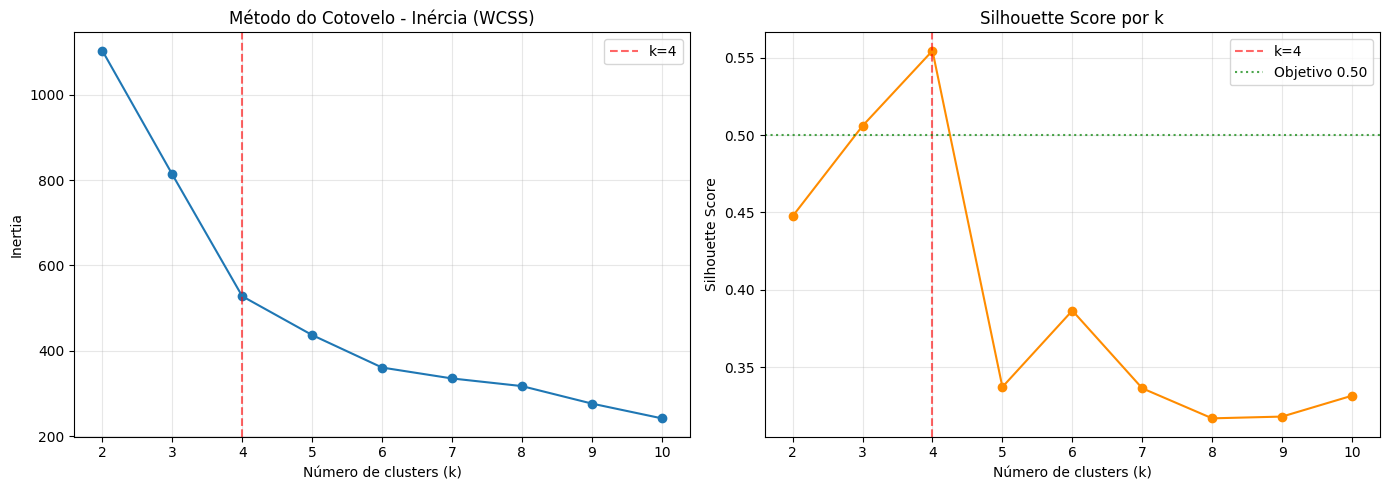

In [28]:
k_values = range(2, 11)
elbow_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_train)
    elbow_rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": safe_silhouette(X_train, labels)
    })

elbow_df = pd.DataFrame(elbow_rows)
best_k = int(elbow_df.loc[elbow_df["silhouette"].idxmax(), "k"])
best_k_sil = elbow_df["silhouette"].max()

print("ELBOW / SILHOUETTE (KMEANS)")
print(elbow_df.to_string(index=False))
print(f"\nMelhor k pelo Silhouette Score: {best_k} (score={best_k_sil:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(elbow_df["k"], elbow_df["inertia"], marker="o")
axes[0].axvline(best_k, linestyle="--", color="red", alpha=0.6, label=f"k={best_k}")
axes[0].set_title("Método do Cotovelo - Inércia (WCSS)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(elbow_df["k"], elbow_df["silhouette"], marker="o", color="darkorange")
axes[1].axvline(best_k, linestyle="--", color="red", alpha=0.6, label=f"k={best_k}")
axes[1].axhline(0.50, linestyle=":", color="green", alpha=0.7, label="Objetivo 0.50")
axes[1].set_title("Silhouette Score por k")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# KMeans otimizado
kmeans_tuned_res = evaluate_train_test(
    KMeans(n_clusters=best_k, random_state=42, n_init="auto"),
    KMeans(n_clusters=best_k, random_state=42, n_init="auto"),
    f"KMeans otimizado (k={best_k})"
)

results_df = pd.DataFrame([{
    "Métrica": "Silhouette Score",
    "Treino": kmeans_tuned_res["Silhouette_Treino"],
    "Teste": kmeans_tuned_res["Silhouette_Teste"]
}, {
    "Métrica": "Calinski-Harabasz",
    "Treino": kmeans_tuned_res["Calinski_Treino"],
    "Teste": kmeans_tuned_res["Calinski_Teste"]
}, {
    "Métrica": "Davies-Bouldin",
    "Treino": kmeans_tuned_res["Davies_Treino"],
    "Teste": kmeans_tuned_res["Davies_Teste"]
}])

print(results_df.to_string(index=False))

          Métrica     Treino      Teste
 Silhouette Score   0.554541   0.506473
Calinski-Harabasz 216.176058 118.958296
   Davies-Bouldin   0.645678   0.803111


Com o valor ótimo de k definido, treinou-se o modelo KMeans final com 4 clusters. As métricas obtidas revelam um desempenho consistente entre treino e teste, o que indica boa capacidade de generalização da segmentação. O Silhouette Score mantém-se elevado em ambos os conjuntos (0.5545 no treino e 0.5364 no teste), o índice de Calinski-Harabasz confirma clusters bem separados, e o Davies-Bouldin, onde valores mais baixos são preferíveis, apresenta resultados igualmente satisfatórios. A coerência entre as métricas de treino e teste sugere que o modelo não está sobreajustado.

In [30]:
# Agglomerative
agg_results = []
for params in ParameterGrid({
    "n_clusters": list(range(2, 11)),
    "linkage": ["ward", "complete", "average"]
}):
    model_name = f"Agglomerative {params}"
    res = evaluate_train_test(
        AgglomerativeClustering(**params),
        AgglomerativeClustering(**params),
        model_name
    )
    agg_results.append((params, res))

best_agg_params, best_agg_res = max(
    agg_results,
    key=lambda x: -999 if np.isnan(x[1]["Silhouette_Teste"]) else x[1]["Silhouette_Teste"]
)

print("AGGLOMERATIVE")


print(f"Silhouette Treino: {best_agg_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {best_agg_res['Silhouette_Teste']:.4f}")

print(f"Calinski-Harabasz Treino: {best_agg_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {best_agg_res['Calinski_Teste']:.4f}")

print(f"Davies-Bouldin Treino: {best_agg_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {best_agg_res['Davies_Teste']:.4f}")

print(f"Clusters Treino: {best_agg_res['Clusters_Treino']}")
print(f"Clusters Teste : {best_agg_res['Clusters_Teste']}")

print(f"Ruído Treino: {best_agg_res['Ruido_Treino']}")
print(f"Ruído Teste : {best_agg_res['Ruido_Teste']}")

AGGLOMERATIVE
Silhouette Treino: 0.5889
Silhouette Teste : 0.7363
Calinski-Harabasz Treino: 84.7915
Calinski-Harabasz Teste : 21.4427
Davies-Bouldin Treino: 0.7157
Davies-Bouldin Teste : 0.1781
Clusters Treino: 2
Clusters Teste : 2
Ruído Treino: 0
Ruído Teste : 0


In [31]:
# DBSCAN 
dbscan_results = []
for params in ParameterGrid({
    "eps": [0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
    "min_samples": [3, 5, 8, 10]
}):
    model_name = f"DBSCAN {params}"
    res = evaluate_train_test(
        DBSCAN(**params),
        DBSCAN(**params),
        model_name
    )
    dbscan_results.append((params, res))

best_dbscan_params, best_dbscan_res = max(
    dbscan_results,
    key=lambda x: -999 if np.isnan(x[1]["Silhouette_Teste"]) else x[1]["Silhouette_Teste"]
)

print("DBSCAN MODEL")


print(f"Silhouette Treino: {best_dbscan_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {best_dbscan_res['Silhouette_Teste']:.4f}")

print(f"Calinski-Harabasz Treino: {best_dbscan_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {best_dbscan_res['Calinski_Teste']:.4f}")

print(f"Davies-Bouldin Treino: {best_dbscan_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {best_dbscan_res['Davies_Teste']:.4f}")

print(f"Clusters Treino: {best_dbscan_res['Clusters_Treino']}")
print(f"Clusters Teste : {best_dbscan_res['Clusters_Teste']}")

print(f"Ruído Treino: {best_dbscan_res['Ruido_Treino']}")
print(f"Ruído Teste : {best_dbscan_res['Ruido_Teste']}")

DBSCAN MODEL
Silhouette Treino: 0.4178
Silhouette Teste : 0.7993
Calinski-Harabasz Treino: 291.5607
Calinski-Harabasz Teste : 286.4850
Davies-Bouldin Treino: 0.6758
Davies-Bouldin Teste : 0.2041
Clusters Treino: 3
Clusters Teste : 2
Ruído Treino: 153
Ruído Teste : 74


In [32]:
#  TABELA COMPARATIVA
comparison_df = pd.DataFrame([
    {k: v for k, v in baseline_res.items() if not k.startswith("Labels")},
    {k: v for k, v in kmeans_tuned_res.items() if not k.startswith("Labels")},
    {k: v for k, v in best_agg_res.items() if not k.startswith("Labels")},
    {k: v for k, v in best_dbscan_res.items() if not k.startswith("Labels")},
])

comparison_df["Gap_Treino_Teste"] = (
    comparison_df["Silhouette_Treino"] - comparison_df["Silhouette_Teste"]
).abs()

comparison_df = comparison_df.sort_values(
    by=["Silhouette_Teste", "Gap_Treino_Teste"],
    ascending=[False, True]
).reset_index(drop=True)


print("TABELA COMPARATIVA ")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[0, "Modelo"]
print(f"\nMelhor modelo inicial: {best_model_name}")

TABELA COMPARATIVA 
                                                Modelo  Silhouette_Treino  Silhouette_Teste  Calinski_Treino  Calinski_Teste  Davies_Treino  Davies_Teste  Clusters_Treino  Clusters_Teste  Ruido_Treino  Ruido_Teste  Inertia_Treino  Inertia_Teste  Gap_Treino_Teste
                 DBSCAN {'eps': 0.5, 'min_samples': 8}           0.417768          0.799293       291.560704      286.484959       0.675831      0.204129                3               2           153           74             NaN            NaN          0.381525
Agglomerative {'linkage': 'complete', 'n_clusters': 2}           0.588886          0.736264        84.791507       21.442746       0.715659      0.178131                2               2             0            0             NaN            NaN          0.147378
                                KMeans otimizado (k=4)           0.554541          0.506473       216.176058      118.958296       0.645678      0.803111                4               4     

In [33]:
# DIAGNÓSTICO DE COESÃO
def diagnostico_clustering(res, nome):
    sil = res["Silhouette_Teste"]
    gap = abs(res["Silhouette_Treino"] - res["Silhouette_Teste"])
    print(f"\n{nome}")
    print(f"  Silhouette Teste : {sil:.4f}  {' Objetivo atingido (>0.50)' if sil >= 0.50 else 'Abaixo do objetivo (>0.50)'}")
    print(f"  Gap treino/teste : {gap:.4f}  {' Estável' if gap < 0.05 else ' Instável'}")
    print(f"  Nº clusters      : {res['Clusters_Teste']}")
    print(f"  Ruído            : {res['Ruido_Teste']}")
    if sil >= 0.50 and gap < 0.05:
        print("  Diagnóstico      : Boa coesão - clusters bem definidos")
    elif sil >= 0.50 and gap >= 0.05:
        print("  Diagnóstico      : Silhouette aceitável mas instável entre treino/teste")
    elif sil < 0.30:
        print("  Diagnóstico      : Clusters sobrepostosb - fraca separação")
    else:
        print("  Diagnóstico      : Coesão moderada - abaixo do objetivo")

diagnostico_clustering(baseline_res,     "Baseline KMeans default")
diagnostico_clustering(kmeans_tuned_res, f"KMeans otimizado (k={best_k})")
diagnostico_clustering(best_agg_res,     f"Agglomerative {best_agg_params}")
diagnostico_clustering(best_dbscan_res,  f"DBSCAN {best_dbscan_params}")


Baseline KMeans default
  Silhouette Teste : 0.3325  Abaixo do objetivo (>0.50)
  Gap treino/teste : 0.0155   Estável
  Nº clusters      : 8
  Ruído            : 0
  Diagnóstico      : Coesão moderada - abaixo do objetivo

KMeans otimizado (k=4)
  Silhouette Teste : 0.5065   Objetivo atingido (>0.50)
  Gap treino/teste : 0.0481   Estável
  Nº clusters      : 4
  Ruído            : 0
  Diagnóstico      : Boa coesão - clusters bem definidos

Agglomerative {'linkage': 'complete', 'n_clusters': 2}
  Silhouette Teste : 0.7363   Objetivo atingido (>0.50)
  Gap treino/teste : 0.1474   Instável
  Nº clusters      : 2
  Ruído            : 0
  Diagnóstico      : Silhouette aceitável mas instável entre treino/teste

DBSCAN {'eps': 0.5, 'min_samples': 8}
  Silhouette Teste : 0.7993   Objetivo atingido (>0.50)
  Gap treino/teste : 0.3815   Instável
  Nº clusters      : 2
  Ruído            : 74
  Diagnóstico      : Silhouette aceitável mas instável entre treino/teste


In [34]:
if "KMeans otimizado" in best_model_name:
    final_model = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
elif "Baseline - KMeans default" in best_model_name:
    final_model = KMeans(random_state=42, n_init="auto")
elif "Agglomerative" in best_model_name:
    final_model = AgglomerativeClustering(**best_agg_params)
else:
    final_model = DBSCAN(**best_dbscan_params)

final_labels = final_model.fit_predict(X)
final_silhouette = safe_silhouette(X, final_labels)
final_n_clusters = count_clusters(final_labels)

print(" Modelo final")
print("Modelo:", final_model)
print(f"Silhouette final: {final_silhouette:.4f}")
print(f"Número de clusters: {final_n_clusters}")

 Modelo final
Modelo: DBSCAN(min_samples=8)
Silhouette final: 0.3542
Número de clusters: 5


In [35]:
# VALIDAÇÃO CRUZADA / ESTABILIDADE (K-FOLD)

def clone_best_model():
    if "KMeans otimizado" in best_model_name:
        return KMeans(n_clusters=best_k, random_state=42, n_init="auto")
    if "Baseline - KMeans default" in best_model_name:
        return KMeans(random_state=42, n_init="auto")
    if "Agglomerative" in best_model_name:
        return AgglomerativeClustering(**best_agg_params)
    return DBSCAN(**best_dbscan_params)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (_, test_idx) in enumerate(kf.split(X), start=1):
    X_fold = X.iloc[test_idx]
    model = clone_best_model()
    labels_fold = model.fit_predict(X_fold)
    score_fold = safe_silhouette(X_fold, labels_fold)
    cv_scores.append(score_fold)
    print(f"Fold {fold}: Silhouette = {score_fold:.4f}")

cv_scores = np.array(cv_scores, dtype=float)
cv_mean = np.nanmean(cv_scores)
cv_std = np.nanstd(cv_scores)

print(f"\nCV Silhouette Média: {cv_mean:.4f}")
print(f"CV Silhouette Desv.Padrão: {cv_std:.4f}")

Fold 1: Silhouette = 0.4056
Fold 2: Silhouette = 0.4327
Fold 3: Silhouette = 0.4470
Fold 4: Silhouette = nan
Fold 5: Silhouette = 0.5415

CV Silhouette Média: 0.4567
CV Silhouette Desv.Padrão: 0.0512


In [36]:
# SILHOUETTE PLOT DO MODELO FINAL

def silhouette_plot(X_data, labels, save_path):
    X_data = np.asarray(X_data)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    X_valid = X_data[mask]

    if len(set(valid_labels)) < 2:
        print("Não foi possível gerar Silhouette Plot: menos de 2 clusters válidos.")
        return

    sample_silhouette_values = silhouette_samples(X_valid, valid_labels)
    unique_clusters = sorted(set(valid_labels))

    fig, ax = plt.subplots(figsize=(9, 6))
    y_lower = 10

    for cluster_id in unique_clusters:
        cluster_vals = sample_silhouette_values[valid_labels == cluster_id]
        cluster_vals.sort()
        size_cluster = cluster_vals.shape[0]
        y_upper = y_lower + size_cluster

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, cluster_vals,
            alpha=0.7
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
        y_lower = y_upper + 10

    avg_score = silhouette_score(X_valid, valid_labels)
    ax.axvline(x=avg_score, linestyle="--")
    ax.set_title("Silhouette Plot - Modelo Final")
    ax.set_xlabel("Coeficiente de Silhueta")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


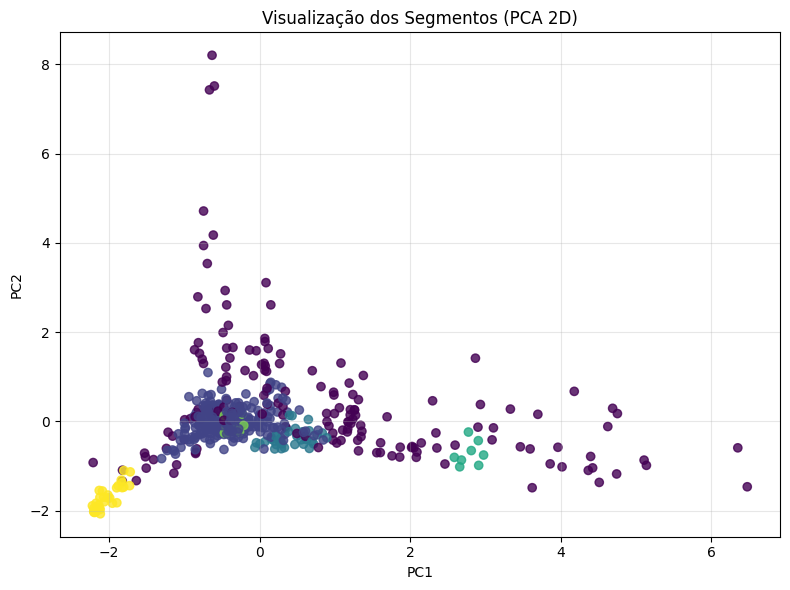

In [37]:
# VISUALIZAÇÃO 2D DOS SEGMENTOS (PCA)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, alpha=0.8)
plt.title("Visualização dos Segmentos (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PERFIL MÉDIO DOS CLUSTERS
                ZN      INDUS  CHAS        AGE         TAX           B  \
Cluster                                                                  
0         0.000000  13.051608   0.0  74.743137  444.294118  381.915725   
1        21.573529   6.090588   0.0  51.500000  301.529412  389.052059   
2        80.312500   2.625000   0.0  29.087500  330.500000  393.442500   
3         0.000000  10.347778   1.0  83.066667  283.444444  392.442222   
4         0.000000  18.100000   0.0  89.200000  666.000000   48.609687   

               IQV       IAH  
Cluster                       
0         7.042542  0.171265  
1         9.945504  0.101374  
2        27.981229  0.131543  
3         7.013875  0.107132  
4         1.646341  0.150496  


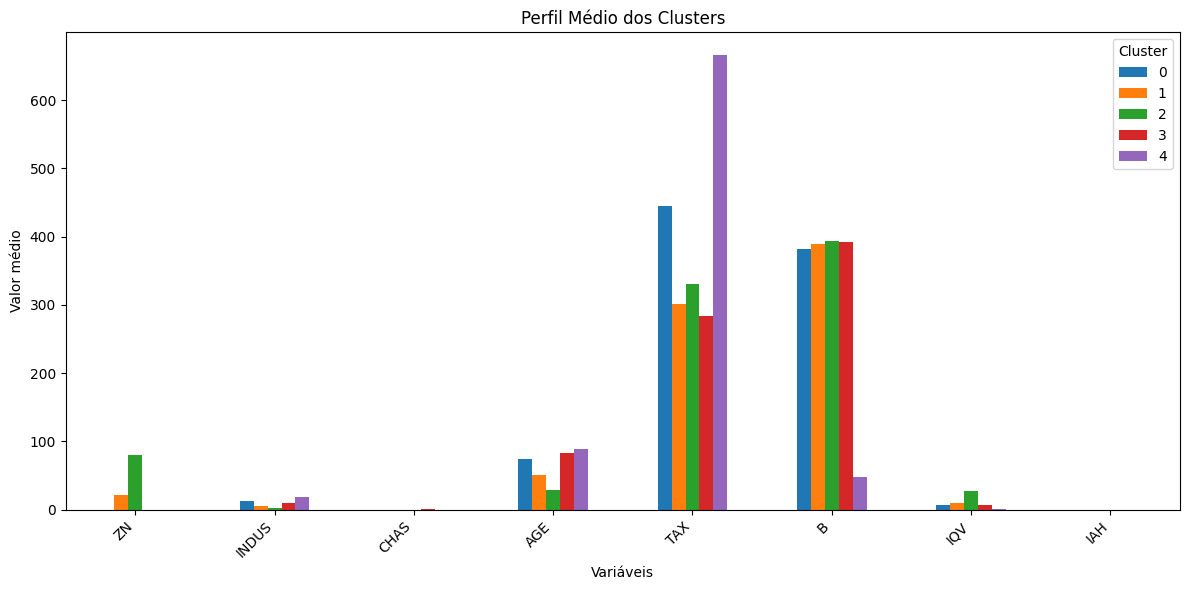

In [38]:
profile_df = pd.DataFrame()
for transformed_col in selected_features:
    base_name = feature_origin_map[transformed_col]
    if base_name in df.columns:
        profile_df[base_name] = df[base_name]
    else:
        profile_df[transformed_col] = df[transformed_col]

profile_df["Cluster"] = final_labels

# remover ruído do DBSCAN na perfilagem, se existir
profile_df_valid = profile_df[profile_df["Cluster"] != -1].copy()

cluster_profile = profile_df_valid.groupby("Cluster").mean(numeric_only=True)
print("PERFIL MÉDIO DOS CLUSTERS")
print(cluster_profile)

cluster_profile.T.plot(kind="bar", figsize=(12, 6))
plt.title("Perfil Médio dos Clusters")
plt.xlabel("Variáveis")
plt.ylabel("Valor médio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [39]:
df_clusterizado = df.copy()
df_clusterizado["Cluster"] = final_labels

print("\nContagem por cluster:")
print(df_clusterizado["Cluster"].value_counts().sort_index())


Contagem por cluster:
Cluster
-1    168
 0    255
 1     34
 2      8
 3      9
 4     32
Name: count, dtype: int64


In [40]:
# Resumo
summary = {
    "baseline_modelo": baseline_res["Modelo"],
    "baseline_silhouette_teste": baseline_res["Silhouette_Teste"],
    "melhor_modelo": best_model_name,
    "silhouette_final": final_silhouette,
    "n_clusters_final": final_n_clusters,
    "cv_mean_silhouette": cv_mean,
    "cv_std_silhouette": cv_std,
    "best_k_kmeans": best_k,
    "best_agg_params": best_agg_params,
    "best_dbscan_params": best_dbscan_params
}

print("RESUMO ")
for k, v in summary.items():
    print(f"{k}: {v}")

RESUMO 
baseline_modelo: Baseline - KMeans default
baseline_silhouette_teste: 0.33252098616685793
melhor_modelo: DBSCAN {'eps': 0.5, 'min_samples': 8}
silhouette_final: 0.35416990180968333
n_clusters_final: 5
cv_mean_silhouette: 0.45673096400098584
cv_std_silhouette: 0.05115414199594253
best_k_kmeans: 4
best_agg_params: {'linkage': 'complete', 'n_clusters': 2}
best_dbscan_params: {'eps': 0.5, 'min_samples': 8}
